In [1]:
import scimap as sm
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy as sp
import os
import yaml
from pathlib import Path
from matplotlib import colormaps
import seaborn as sns

Running SCIMAP  2.1.3


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
preprocessed_dir = Path("/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed")
roi_list = [roi for roi in preprocessed_dir.iterdir() if roi.is_dir() and roi.name != '.DS_Store']

In [3]:
#conctenate all the adata files
adata_list = []
for roi in roi_list:
    adata = ad.read_h5ad(roi / "adata.h5ad")
    adata_list.append(adata)
adata = ad.concat(adata_list)

#make obs names unique
adata.obs_names_make_unique()


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.



In [16]:
adata = sm.tl.spatial_interaction (adata,
                         x_coordinate='Cell Center X',
                         y_coordinate='Cell Center Y',
                         phenotype="cell_type",
                         method='knn',
                         permutation=300,
                         imageid='exp_name',
                         subset=None,
                         pval_method='zscore',
                         normalization='conditional',
                         verbose=True,
                         label='scimap_delaunay_conditional_zscore')

Processing Image: ['Run141_ROI11']
Categories (1, object): ['Run141_ROI11']
Identifying the 10 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI16']
Categories (1, object): ['Run141_ROI16']
Identifying the 10 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI7']
Categories (1, object): ['Run141_ROI7']
Identifying the 10 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run141_ROI19']
Categories (1, object): ['Run141_ROI19']
Identifying the 10 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run141_ROI8']
Categories (1, object): ['Run141_ROI8']
Identifying the 10 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run141_ROI17']
Categories (1, object): ['Run141_ROI17']
Identifying the 10 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run141_ROI15']
Categories (1, object): ['Run141_ROI15']
Identifying the 10 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI23']
Categories (1, object): ['Run141_ROI23']
Identifying the 10 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results


In [17]:
heatmap_data = adata.uns['scimap_delaunay_conditional_zscore']
heatmap_data.index = heatmap_data["phenotype"] + "-" + heatmap_data["neighbour_phenotype"]
heatmap_data= heatmap_data.drop(columns=["phenotype", "neighbour_phenotype"])
heatmap_data = heatmap_data.filter(like='zscore', axis=1)
#filter the index to include only interactions with Tumor_cells
heatmap_data = heatmap_data.filter(like="Tumor", axis=0)
ordered_columns = ["zscore_" + roi for roi in ["Run141_ROI11", "Run141_ROI19", "Run141_ROI8", "Run141_ROI17", "Run141_ROI16", "Run141_ROI7", "Run141_ROI15", "Run141_ROI23"]]
heatmap_data = heatmap_data[ordered_columns]
heatmap_data

,zscore_Run141_ROI11,zscore_Run141_ROI19,zscore_Run141_ROI8,zscore_Run141_ROI17,zscore_Run141_ROI16,zscore_Run141_ROI7,zscore_Run141_ROI15,zscore_Run141_ROI23
Actin+_cells-Tumor_cells,-75.465340,-42.095131,-26.223114,-14.803593,-37.375282,-5.838151,-95.085062,-107.317512
B_cells-Tumor_cells,3.344607,-1.044439,-5.002173,-86.096846,-0.925499,2.417511,2.313675,2.028366
CD4+_T_cells-Tumor_cells,-46.376409,-16.551581,-77.720260,-42.994766,-9.989418,4.801100,-5.881430,-3.388533
CD8+_T_cells-Tumor_cells,-28.558309,-13.441145,-41.830287,-27.816088,0.775448,1.616694,2.552289,1.533128
DCs-Tumor_cells,-25.276666,-11.097451,4.631318,-11.770966,NaN,NaN,3.169525,-14.086189
Endothelial_cells-Tumor_cells,-22.631831,-28.447235,-23.634173,-24.105504,6.270552,-15.946741,-67.355641,-60.341256
Epithelial_cells-Tumor_cells,NaN,NaN,NaN,NaN,-29.127458,-15.187936,NaN,NaN
Granulocytes-Tumor_cells,-7.122544,-15.090862,-10.320604,-7.364660,-10.153355,-1.756261,-2.344298,-26.189116
Lymphatic_endothelial_cells-Tumor_cells,0.635599,-14.037332,-33.554467,-23.926266,-12.440823,-5.057099,-6.871388,-30.312990
M1_M2_macrophages-Tumor_cells,1.774817,-12.147357,-17.281966,-15.357277,1.604046,3.987018,-19.443188,-17.836406


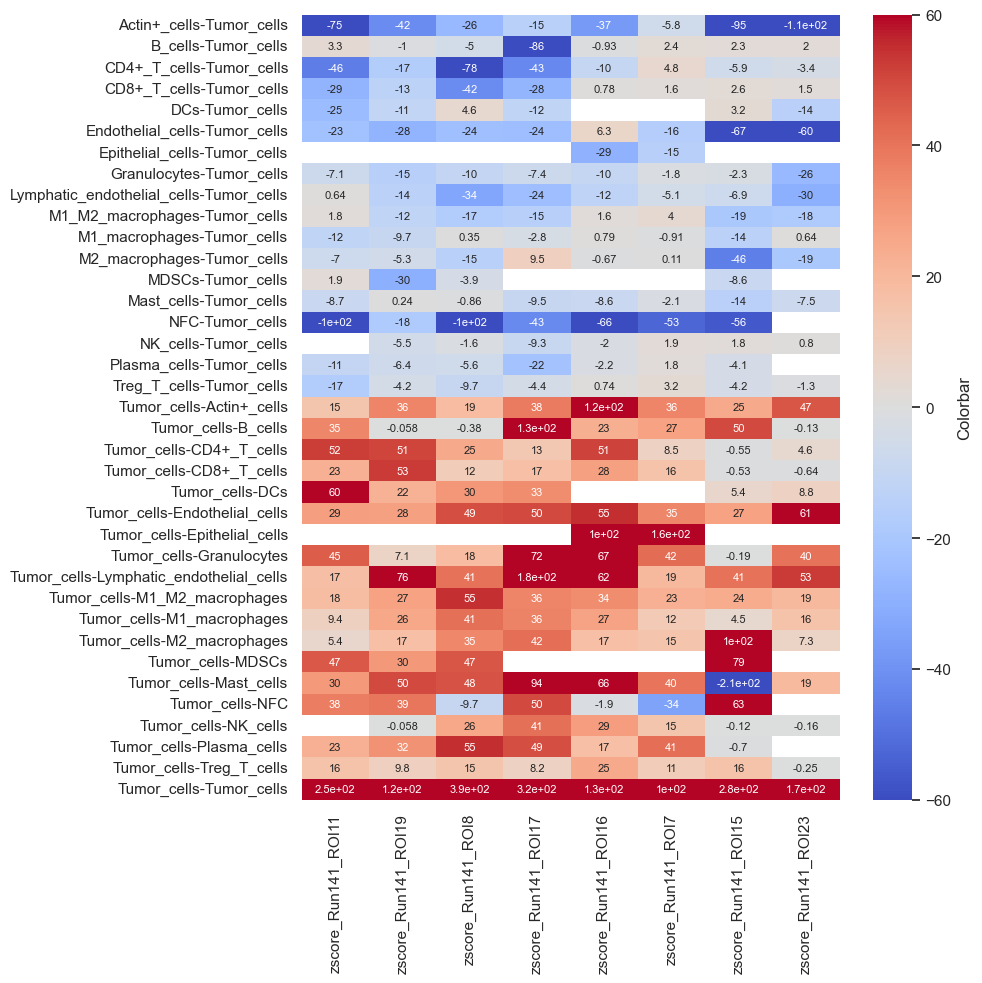

In [18]:
plt.figure(figsize=(10, 10))

# Plot the heatmap
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='coolwarm',
    annot_kws={"size": 8},
    cbar_kws={'label': 'Colorbar'},  # Optional, for better colorbar label
    vmin=-60,
    vmax=60
)

# Rotate row labels for better readability
plt.yticks(rotation=0)  # You can adjust this angle as needed (0 for horizontal)

# Adjust layout for better spacing
plt.tight_layout()

plt.show()

In [ ]:
customColors = { 'Unknown' : '#e5e5e5',
                'CD8+ T' : '#ffd166',
                'Non T CD4+ cells' : '#06d6a0',
                'CD4+ T' : '#118ab2',
                'ECAD+' : '#ef476f',
                'Immune' : '#073b4c',
                'KI67+ ECAD+' : '#000000'
    }

In [78]:
long_term

array(['Run141_ROI11', 'Run141_ROI19', 'Run141_ROI8', 'Run141_ROI17'],
      dtype='<U12')

In [50]:
cell_colors = {
    "Tumor_cells": "#FF6347",  # Tomato red
    "Actin+_cells": "grey",  # Steel blue
    "CD8+_T_cells": "#32CD32",  # Lime green
    "M1_macrophages": "#FFD700",  # Gold
    "Treg_T_cells": "#8A2BE2",  # Blue violet
    "M2_macrophages": "#00FA9A",  # Medium spring green
    "DCs": "#FF4500",  # Orange red
    "Endothelial_cells": "#2E8B57",  # Sea green
    "CD4+_T_cells": "#9932CC",  # Dark orchid
    "Mast_cells": "#DAA520",  # Goldenrod
    "Lymphatic_endothelial_cells": "#A52A2A",  # Brown
    "Granulocytes": "#C71585",  # Medium violet red
    "M1_M2_macrophages": "#D2691E",  # Chocolate
    "Plasma_cells": "#8B0000",  # Dark red
    "B_cells": "#4169E1",  # Royal blue
    "MDSCs": "#B22222",  # Firebrick
    "Epithelial_cells": "#228B22",  # Forest green
    "NK_cells": "#FF1493"  # Deep pink
}

In [56]:
adata.obs.outcome_group

0           long_term survival
1           long_term survival
2           long_term survival
3           long_term survival
4           long_term survival
                  ...         
16649-6    short_term survival
16650-6    short_term survival
16651-6    short_term survival
16652-6    short_term survival
16653-6    short_term survival
Name: outcome_group, Length: 179902, dtype: category
Categories (2, object): ['long_term survival', 'short_term survival']

In [61]:
long_term = adata.obs[adata.obs["outcome_group"] == "long_term survival"].exp_name.unique().astype(str)
short_term = adata.obs[adata.obs["outcome_group"] == "short_term survival"].exp_name.unique().astype(str)

In [76]:
short_term

array(['Run141_ROI16', 'Run141_ROI7', 'Run141_ROI15', 'Run141_ROI23'],
      dtype='<U12')

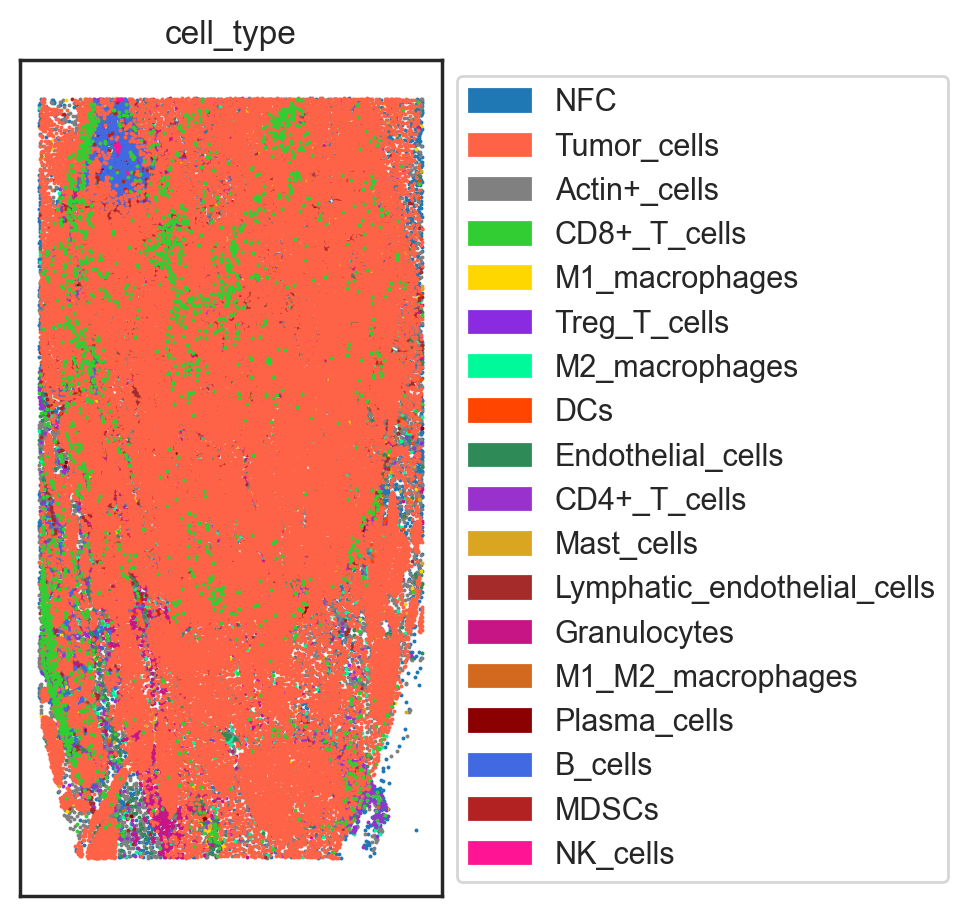

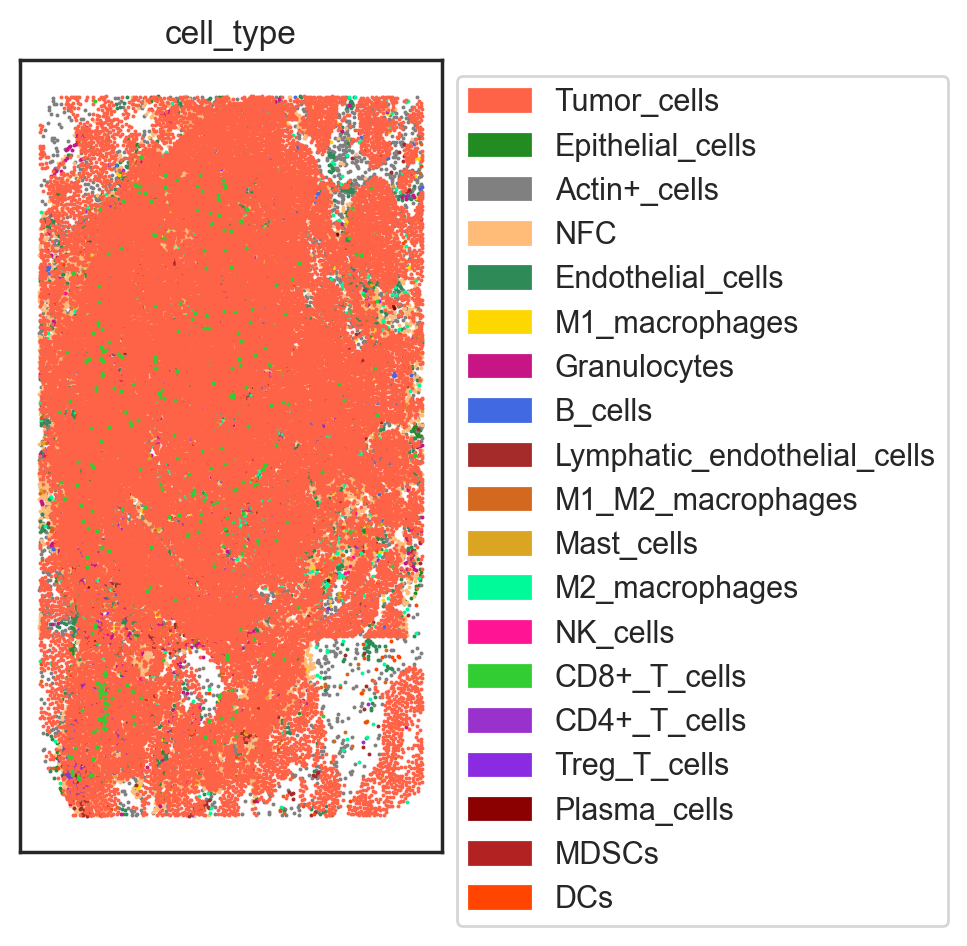

In [108]:
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=long_term, imageid="exp_name", customColors=cell_colors)
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=short_term, imageid="exp_name", customColors=cell_colors)


In [96]:
ordered_columns

['zscore_Run141_ROI11',
 'zscore_Run141_ROI19',
 'zscore_Run141_ROI8',
 'zscore_Run141_ROI17',
 'zscore_Run141_ROI16',
 'zscore_Run141_ROI7',
 'zscore_Run141_ROI15',
 'zscore_Run141_ROI23']

TypeError: object of type 'list_reverseiterator' has no len()

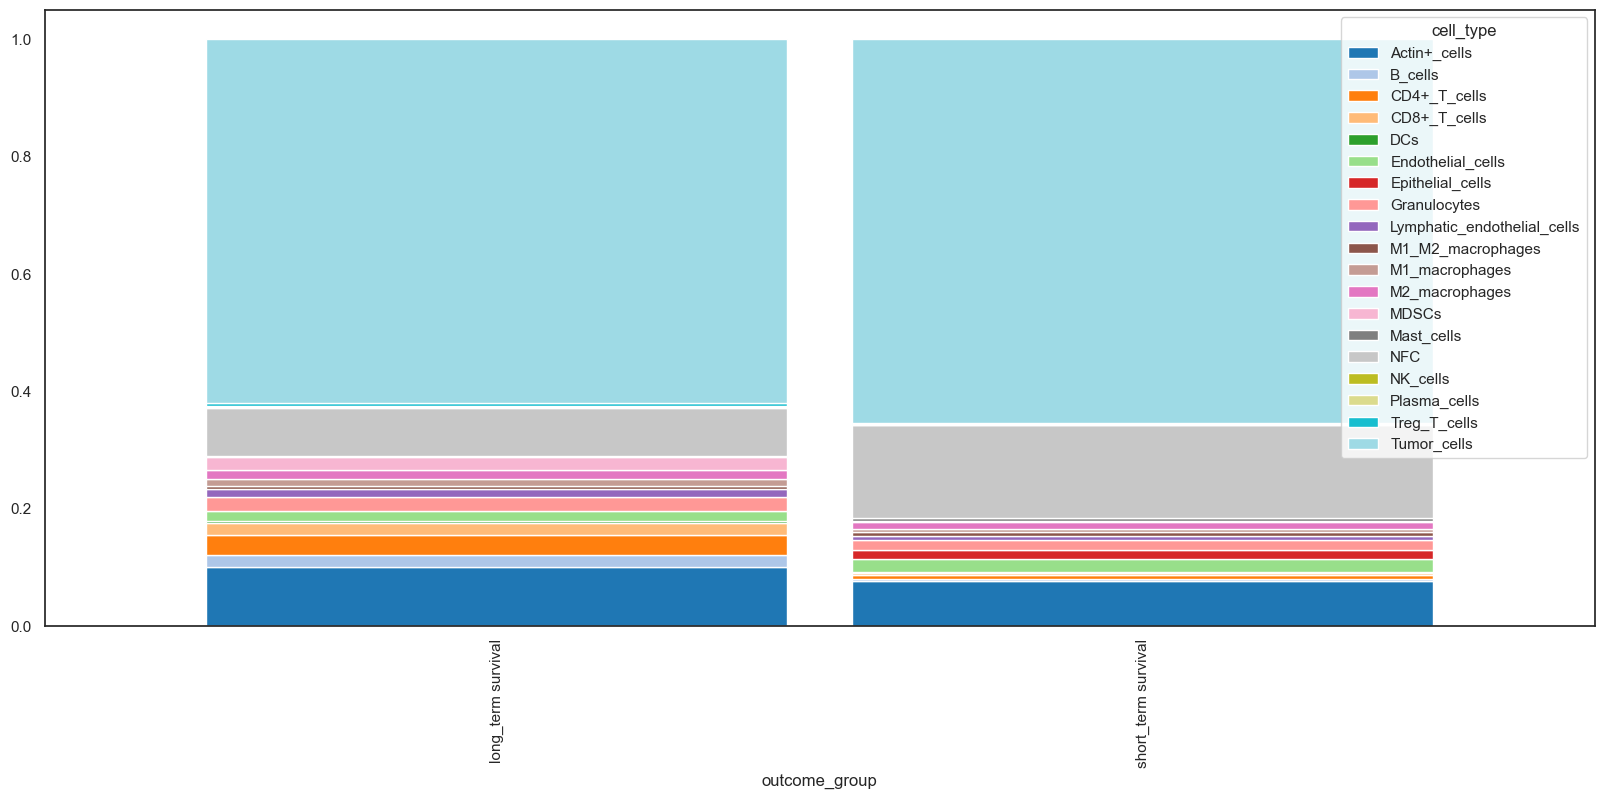

In [115]:
sm.pl.stacked_barplot(adata, x_axis="outcome_group", y_axis="cell_type", method="percent", plot_tool='matplotlib', matplotlib_legend_loc=3, figsize=(20, 8))

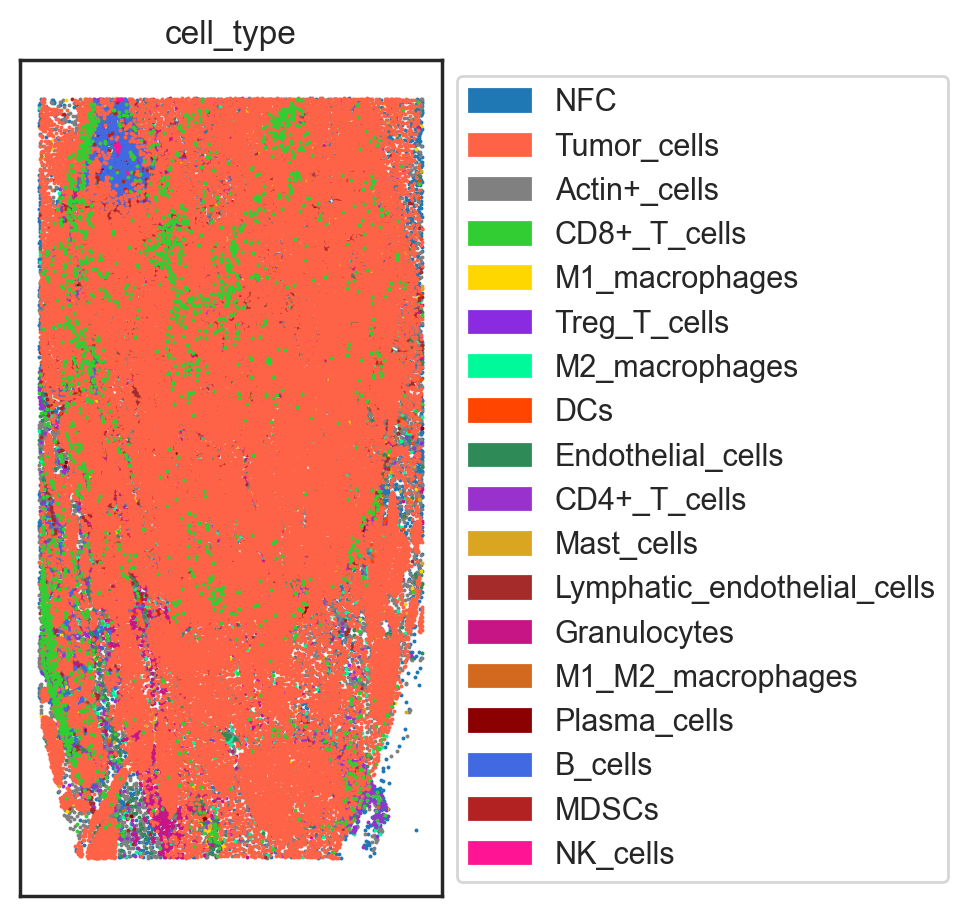

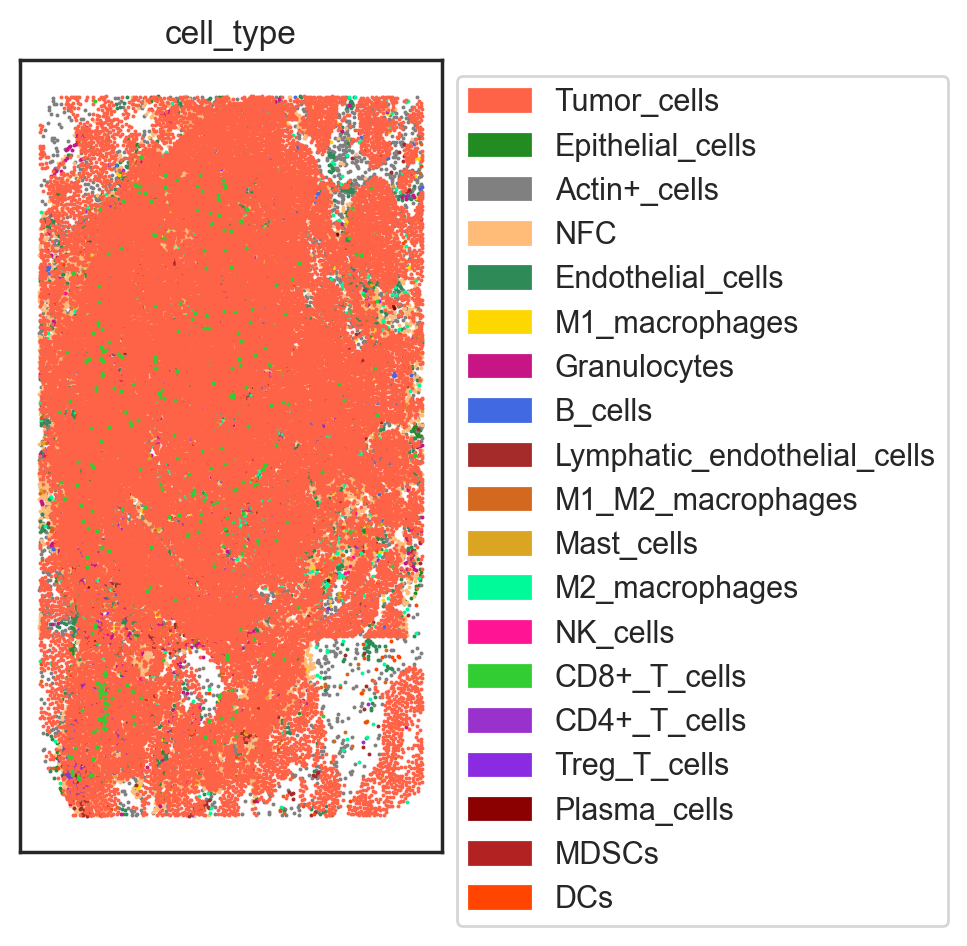

In [70]:
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=long_term, imageid="exp_name", customColors=cell_colors)
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=short_term, imageid="exp_name", customColors=cell_colors)

In [119]:
long_term_zscore = ["zscore_" + roi for roi in ["Run141_ROI11", "Run141_ROI19", "Run141_ROI8", "Run141_ROI17"]]
short_term_zscore = ["zscore_" + roi for roi in ["Run141_ROI16", "Run141_ROI7", "Run141_ROI15", "Run141_ROI23"]]


In [121]:
boxplot_data = heatmap_data.melt(var_name='variable', value_name='value', ignore_index=False)
boxplot_data = boxplot_data.filter(like = "CD8+_T_cells-Tumor_cells", axis=0)
boxplot_data["group"] = np.where(boxplot_data["variable"].isin(long_term_zscore), "Long_term", "Short_term")
boxplot_data


,variable,value,group
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI11,-15.521816,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI19,-8.852351,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI8,-28.027726,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI17,-14.573462,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI16,0.350344,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI7,1.055972,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI15,1.813534,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI23,1.628872,Short_term


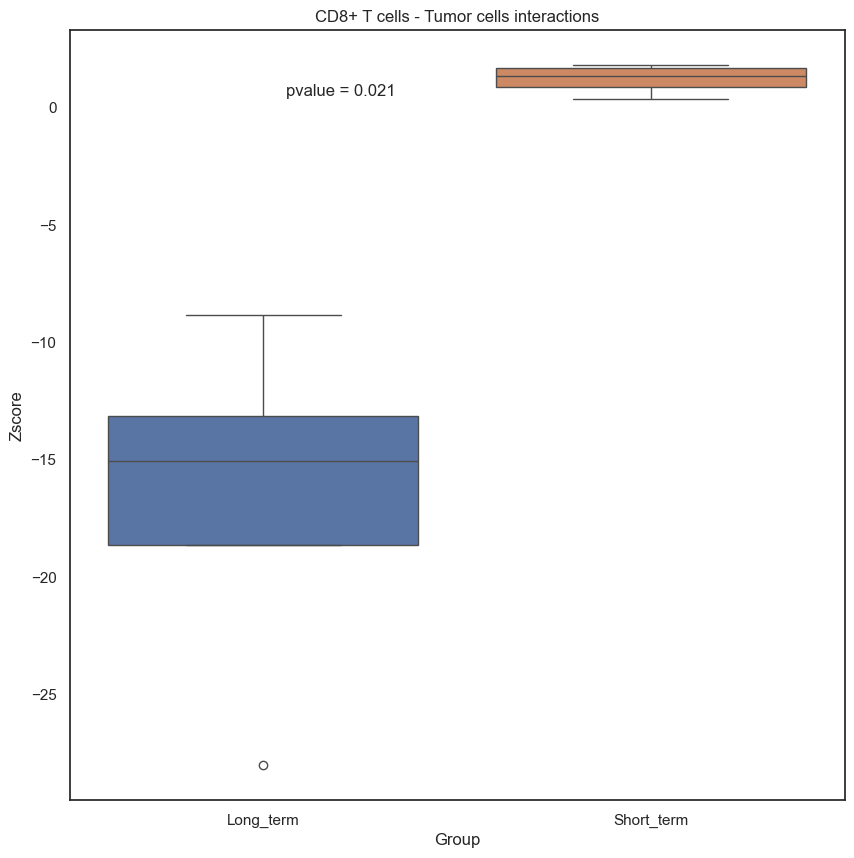

In [136]:
#build a boxplot based on boxplt_data based on matplot
#add the jitter to the boxplot
plt.figure(figsize=(10, 10))
sns.boxplot(x='group', y='value', hue='group', data=boxplot_data)
#add title to box plot and labels
plt.title('CD8+ T cells - Tumor cells interactions')
plt.xlabel('Group')
plt.ylabel('Zscore')
#calculate pvalue based on wilcox and add it to the plot
pvalue = sp.stats.ranksums(boxplot_data[boxplot_data["group"] == "Long_term"]["value"], boxplot_data[boxplot_data["group"] == "Short_term"]["value"]).pvalue.round(3)
plt.text(0.2, 0.5, "pvalue = " + str(pvalue), fontsize=12, ha='center')
plt.show()

In [147]:
adata_long = adata[adata.obs["exp_name"].isin(["Run141_ROI11", "Run141_ROI19", "Run141_ROI8", "Run141_ROI17"])]
adata_short = adata[adata.obs["exp_name"].isin(["Run141_ROI16", "Run141_ROI7", "Run141_ROI15", "Run141_ROI23"])]

In [153]:
adata = sm.tl.spatial_distance(adata, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')

Processing Image: Run141_ROI11
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run141_ROI19
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run141_ROI15
Processing Image: Run141_ROI23


In [150]:
adata_long = sm.tl.spatial_distance(adata_long, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')
adata_short = sm.tl.spatial_distance(adata_short, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')

Processing Image: Run141_ROI11
Processing Image: Run141_ROI19
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run141_ROI15
Processing Image: Run141_ROI23


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/spatial_distance.py:143: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



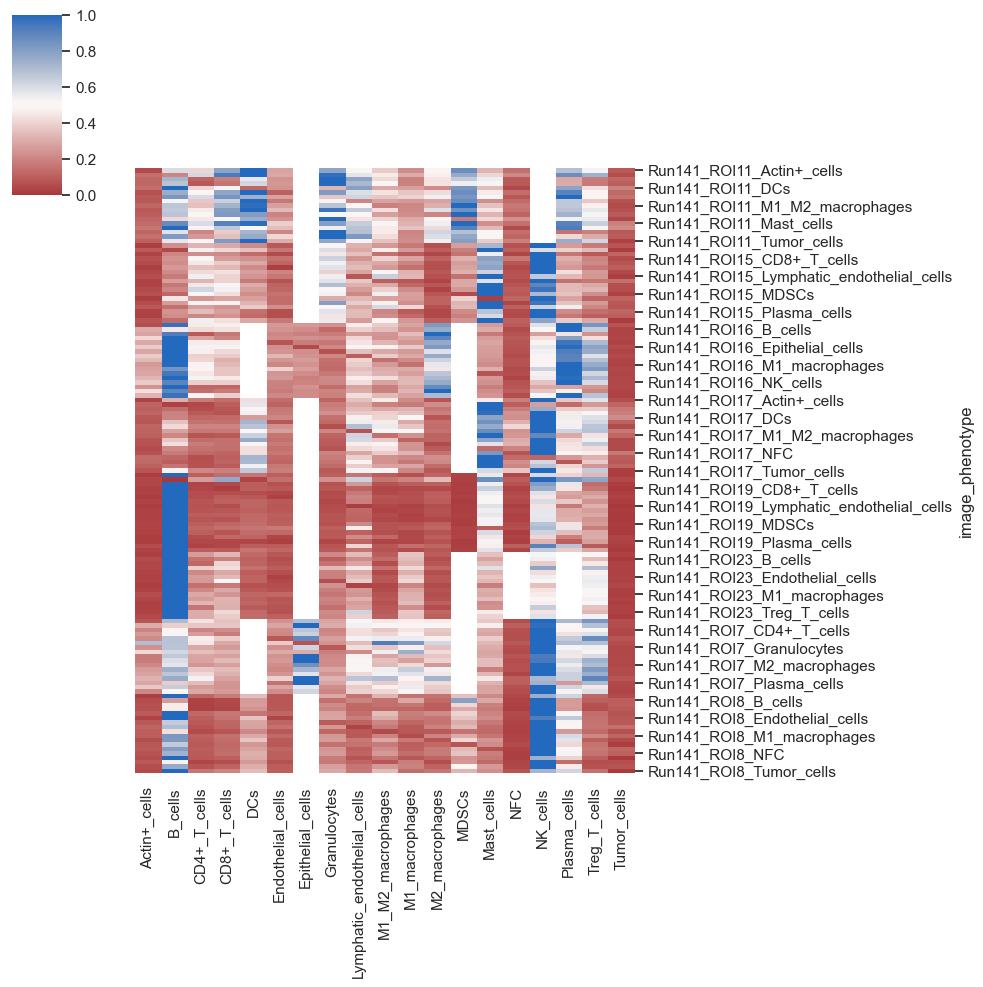

In [157]:
sm.pl.spatial_distance(adata, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance', heatmap_summarize=False)

In [1]:
sm.pl.spatial_distance(adata_long, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance')
sm.pl.spatial_distance(adata_short, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance')


NameError: name 'sm' is not defined